# CAM Variants on RSNA. Localization and Faithfulness Evaluation

**Project:** Multimodal Explainable AI for Chest Radiology, Master 2 ISI
**Scope:** generate five CAM variants on the trained ResNet50 and evaluate them with the two protocols of the SOTA table. First the localization protocol of the Nature Machine Intelligence 2022 benchmark, mIoU and hit rate against expert boxes. Second the perturbation protocol, deletion and insertion, that needs no annotation. Together they answer research question one with numbers.

**Required inputs to attach:**
1. The competition `rsna-pneumonia-detection-challenge` for the DICOM images
2. Your results dataset containing `resnet50_rsna_best.pth`, `rsna_test_predictions.csv` and `rsna_bboxes_eval.csv`

**Settings:** GPU T4 and Internet On for the grad cam library.

**Outputs saved in `/kaggle/working`:**
1. `heatmaps/` npy heatmaps and png overlays per image and method
2. `cam_localization_scores.csv` and `cam_faithfulness_scores.csv`
3. `cam_summary.csv` the final ranking table of the five methods
4. Comparison figures for the thesis


In [1]:
# The pytorch grad cam library implements the five compared variants
!pip install grad-cam --quiet

import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pydicom
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from torchvision import models

from pytorch_grad_cam import GradCAM, GradCAMPlusPlus, EigenCAM, LayerCAM, ScoreCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUTPUT_DIR = "/kaggle/working"
HEATMAP_DIR = os.path.join(OUTPUT_DIR, "heatmaps")
os.makedirs(HEATMAP_DIR, exist_ok=True)
print("Device:", DEVICE)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Device: cuda


## Part 1. Resolve paths and reload the trained model

Paths are resolved by search since mount names vary between sessions. The ResNet50 architecture is rebuilt and the trained weights of the classification notebook are loaded in evaluation mode.

In [2]:
ckpt_path = glob.glob("/kaggle/input/**/resnet50_rsna_best.pth", recursive=True)[0]
pred_path = glob.glob("/kaggle/input/**/rsna_test_predictions.csv", recursive=True)[0]
bbox_path = glob.glob("/kaggle/input/**/rsna_bboxes_eval.csv", recursive=True)[0]
labels_path = glob.glob("/kaggle/input/**/stage_2_train_labels.csv", recursive=True)[0]
IMG_DIR = os.path.join(os.path.dirname(labels_path), "stage_2_train_images")

preds = pd.read_csv(pred_path)
bboxes = pd.read_csv(bbox_path)
preds["filepath"] = preds["patientId"].apply(lambda p: os.path.join(IMG_DIR, p + ".dcm"))
preds = preds[preds["filepath"].apply(os.path.exists)].reset_index(drop=True)
print("Test predictions:", len(preds), " expert boxes:", len(bboxes))

model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, 2)
model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
model = model.to(DEVICE).eval()
print("Model loaded from", os.path.basename(ckpt_path))

Test predictions: 2973  expert boxes: 1917
Model loaded from resnet50_rsna_best.pth


## Part 2. Build the study set

Two subsets are drawn from the test predictions. The localization subset contains fifty correctly classified pneumonia images that have expert boxes, because mIoU and hit rate are only defined where a ground truth box exists, following the Nature Machine Intelligence 2022 protocol that evaluates localization on true positives. The qualitative subset adds examples of the four confusion categories, since heatmaps of misclassified images reveal what confused the model, a use of explanations promoted by the PLOS ONE 2024 study.

In [3]:
def category(row):
    if row["target"] == 1 and row["prediction"] == 1:
        return "true_positive"
    if row["target"] == 0 and row["prediction"] == 0:
        return "true_negative"
    if row["target"] == 0 and row["prediction"] == 1:
        return "false_positive"
    return "false_negative"

preds["category"] = preds.apply(category, axis=1)
print(preds["category"].value_counts())

boxed_patients = set(bboxes["patientId"])
loc_pool = preds[(preds["category"] == "true_positive") &
                 (preds["patientId"].isin(boxed_patients))]
loc_set = loc_pool.sample(min(50, len(loc_pool)), random_state=SEED).reset_index(drop=True)

qual_parts = []
for cat in ["true_positive", "true_negative", "false_positive", "false_negative"]:
    pool = preds[preds["category"] == cat]
    qual_parts.append(pool.sample(min(5, len(pool)), random_state=SEED))
qual_set = pd.concat(qual_parts).reset_index(drop=True)

study = pd.concat([loc_set, qual_set]).drop_duplicates("patientId").reset_index(drop=True)
print("Localization set:", len(loc_set), " study set total:", len(study))

category
true_negative     1685
true_positive     1124
false_positive      85
false_negative      79
Name: count, dtype: int64
Localization set: 50  study set total: 65


## Part 3. CAM engines and image loading

The five variants follow the comparison plan of the project, motivated by the arXiv 2025 five CAM comparison of the SOTA table. The target layer is the last convolutional block of ResNet50, layer4, the standard choice recommended by the original Grad-CAM paper because it holds the deepest spatial semantics. Score-CAM uses many forward passes instead of gradients, which explains its longer runtime.

In [4]:
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

preprocess = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

def read_dicom(filepath):
    dcm = pydicom.dcmread(filepath)
    arr = dcm.pixel_array.astype(np.float32)
    arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8) * 255.0
    return arr.astype(np.uint8)

def load_image(filepath):
    arr = read_dicom(filepath)
    img = Image.fromarray(arr).convert("RGB")
    tensor = preprocess(img).unsqueeze(0).to(DEVICE)
    display = np.array(img.resize((IMG_SIZE, IMG_SIZE)), dtype=np.float32) / 255.0
    return tensor, display, arr.shape

target_layers = [model.layer4[-1]]
cam_methods = {
    "gradcam": GradCAM(model=model, target_layers=target_layers),
    "gradcampp": GradCAMPlusPlus(model=model, target_layers=target_layers),
    "eigencam": EigenCAM(model=model, target_layers=target_layers),
    "layercam": LayerCAM(model=model, target_layers=target_layers),
    "scorecam": ScoreCAM(model=model, target_layers=target_layers)
}
print("Methods ready:", list(cam_methods.keys()))

Methods ready: ['gradcam', 'gradcampp', 'eigencam', 'layercam', 'scorecam']


## Part 4. Generate all heatmaps

For every study image and every method the heatmap of the predicted class is computed, stored as a raw npy array for the quantitative parts, and as a png overlay for the figures. The original image height and width are kept so the expert boxes can be rescaled later.

In [5]:
shape_lookup = {}
for i, row in study.iterrows():
    tensor, display, orig_shape = load_image(row["filepath"])
    shape_lookup[row["patientId"]] = orig_shape
    targets = [ClassifierOutputTarget(int(row["prediction"]))]
    for name, cam in cam_methods.items():
        heatmap = cam(input_tensor=tensor, targets=targets)[0]
        np.save(os.path.join(HEATMAP_DIR, f"{row['patientId']}__{name}.npy"), heatmap)
        overlay = show_cam_on_image(display, heatmap, use_rgb=True)
        Image.fromarray(overlay).save(os.path.join(HEATMAP_DIR, f"{row['patientId']}__{name}.png"))
    if (i + 1) % 10 == 0:
        print(f"processed {i + 1} of {len(study)} images")
print("done")

100%|██████████| 128/128 [00:07<00:00, 16.48it/s]


processed 10 of 65 images


100%|██████████| 128/128 [00:07<00:00, 17.46it/s]


processed 20 of 65 images


100%|██████████| 128/128 [00:07<00:00, 17.31it/s]


...

processed 50 of 65 images


100%|██████████| 128/128 [00:07<00:00, 17.48it/s]


processed 60 of 65 images


100%|██████████| 128/128 [00:07<00:00, 17.55it/s]

done


## Part 5. Localization metrics, mIoU and hit rate

The protocol follows the Nature Machine Intelligence 2022 benchmark of the SOTA table, which uses mIoU as primary metric and the hit rate, also called pointing game, as secondary metric, and recommends using them jointly. The heatmap is binarized by keeping the pixels above half of its maximum, the boxes are rescaled from the original resolution to 224, several boxes of one patient are merged into one ground truth mask, and IoU is the intersection over union of the two masks. The hit rate checks whether the single most activated pixel falls inside a ground truth box. The reference point of the benchmark is that even the best method, Grad-CAM, stayed 24 percent of mIoU below expert radiologists.

In [6]:
def gt_mask_for(patient_id):
    # Union of the rescaled expert boxes of one patient as a binary mask
    h, w = shape_lookup[patient_id]
    mask = np.zeros((IMG_SIZE, IMG_SIZE), dtype=bool)
    for _, b in bboxes[bboxes["patientId"] == patient_id].iterrows():
        x1 = int(b["x"] / w * IMG_SIZE)
        y1 = int(b["y"] / h * IMG_SIZE)
        x2 = int((b["x"] + b["width"]) / w * IMG_SIZE)
        y2 = int((b["y"] + b["height"]) / h * IMG_SIZE)
        mask[y1:y2, x1:x2] = True
    return mask

loc_scores = []
for _, row in loc_set.iterrows():
    gt = gt_mask_for(row["patientId"])
    for name in cam_methods:
        heatmap = np.load(os.path.join(HEATMAP_DIR, f"{row['patientId']}__{name}.npy"))
        pred_mask = heatmap >= 0.5 * heatmap.max()
        inter = np.logical_and(pred_mask, gt).sum()
        union = np.logical_or(pred_mask, gt).sum()
        iou = inter / union if union > 0 else 0.0
        peak = np.unravel_index(np.argmax(heatmap), heatmap.shape)
        hit = bool(gt[peak])
        loc_scores.append({"patientId": row["patientId"], "method": name,
                           "iou": iou, "hit": int(hit)})

loc_scores = pd.DataFrame(loc_scores)
loc_scores.to_csv(os.path.join(OUTPUT_DIR, "cam_localization_scores.csv"), index=False)
print(loc_scores.groupby("method")[["iou", "hit"]].mean().round(4))

              iou   hit
method                 
eigencam   0.2310  0.72
gradcam    0.2683  0.70
gradcampp  0.2671  0.74
layercam   0.2660  0.74
scorecam   0.2853  0.72


## Part 6. Faithfulness metrics, deletion and insertion

These two curves come from the RISE paper of Petsiuk and colleagues, BMVC 2018, and quantify whether the highlighted pixels truly drive the decision, independently of any annotation. Deletion removes the most highlighted pixels step by step and a faithful map makes the probability collapse fast, so a lower area is better. Insertion restores the most highlighted pixels onto a blurred image and a faithful map makes the probability recover fast, so a higher area is better.

In [7]:
STEPS = 20

def predicted_prob(tensor, class_idx):
    with torch.no_grad():
        return torch.softmax(model(tensor), dim=1)[0, class_idx].item()

def deletion_insertion(tensor, heatmap, class_idx):
    order = np.argsort(-heatmap.flatten())
    n_pixels = order.size
    base = tensor.clone()
    blurred = F.avg_pool2d(base, kernel_size=25, stride=1, padding=12)
    del_probs, ins_probs = [], []
    for step in range(STEPS + 1):
        k = int(n_pixels * step / STEPS)
        mask = torch.zeros(n_pixels, device=DEVICE)
        if k > 0:
            mask[torch.from_numpy(order[:k].copy()).to(DEVICE)] = 1.0
        mask = mask.view(1, 1, *heatmap.shape)
        del_probs.append(predicted_prob(base * (1 - mask), class_idx))
        ins_probs.append(predicted_prob(blurred * (1 - mask) + base * mask, class_idx))
    return float(np.mean(del_probs)), float(np.mean(ins_probs))

faith_scores = []
for i, row in loc_set.iterrows():
    tensor, _, _ = load_image(row["filepath"])
    class_idx = int(row["prediction"])
    for name in cam_methods:
        heatmap = np.load(os.path.join(HEATMAP_DIR, f"{row['patientId']}__{name}.npy"))
        d, ins = deletion_insertion(tensor, heatmap, class_idx)
        faith_scores.append({"patientId": row["patientId"], "method": name,
                             "deletion_auc": d, "insertion_auc": ins})
    if (i + 1) % 10 == 0:
        print(f"scored {i + 1} of {len(loc_set)} images")

faith_scores = pd.DataFrame(faith_scores)
faith_scores.to_csv(os.path.join(OUTPUT_DIR, "cam_faithfulness_scores.csv"), index=False)

scored 10 of 50 images
scored 20 of 50 images
scored 30 of 50 images
scored 40 of 50 images
scored 50 of 50 images


## Part 7. Final ranking of the five methods

The summary joins the two protocols. mIoU and hit rate measure agreement with expert localization, insertion minus deletion summarizes faithfulness. A method can localize well and be unfaithful or the reverse, which is exactly the reason the Nature Machine Intelligence benchmark recommends joint reading, and a useful discussion point for the thesis.

              iou   hit  deletion_auc  insertion_auc  faithfulness
method                                                            
scorecam   0.2853  0.72        0.7258         0.9811        0.2554
gradcam    0.2683  0.70        0.6874         0.9876        0.3002
gradcampp  0.2671  0.74        0.7001         0.9855        0.2855
layercam   0.2660  0.74        0.7057         0.9844        0.2787
eigencam   0.2310  0.72        0.7637         0.9775        0.2138


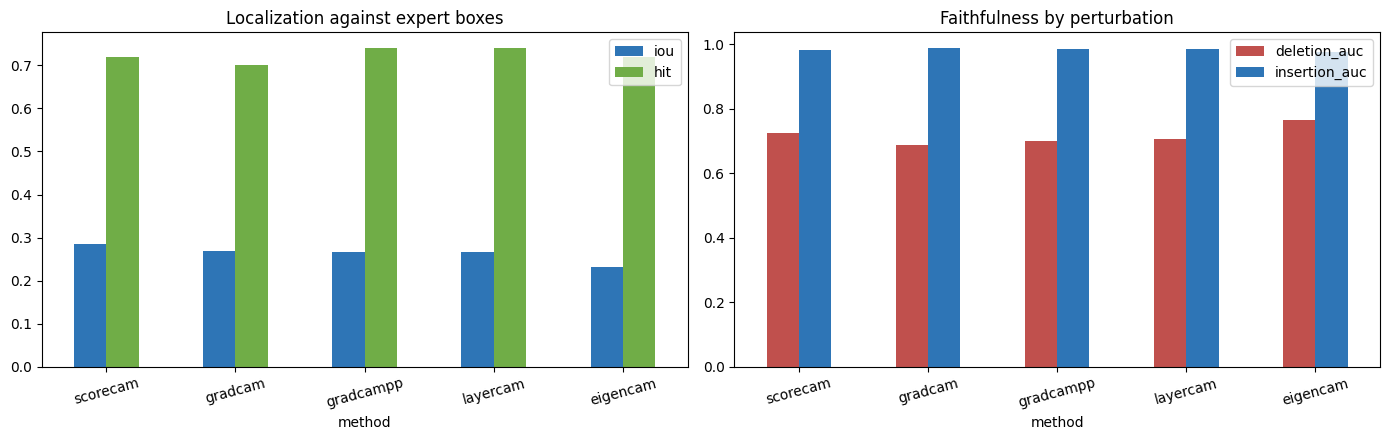

In [8]:
summary = loc_scores.groupby("method")[["iou", "hit"]].mean().join(
    faith_scores.groupby("method")[["deletion_auc", "insertion_auc"]].mean())
summary["faithfulness"] = summary["insertion_auc"] - summary["deletion_auc"]
summary = summary.round(4).sort_values("iou", ascending=False)
summary.to_csv(os.path.join(OUTPUT_DIR, "cam_summary.csv"))
print(summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
summary[["iou", "hit"]].plot(kind="bar", ax=axes[0], color=["#2E75B6", "#70AD47"])
axes[0].set_title("Localization against expert boxes")
axes[0].tick_params(axis="x", rotation=15)
summary[["deletion_auc", "insertion_auc"]].plot(kind="bar", ax=axes[1],
    color=["#C0504D", "#2E75B6"])
axes[1].set_title("Faithfulness by perturbation")
axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "cam_metrics_barplots.png"), dpi=200, bbox_inches="tight")
plt.show()

## Part 8. Qualitative comparison figure

One image per confusion category, the original with its expert boxes when they exist, then the five heatmaps. This figure and the summary table are the visual and numerical answers to research question one.

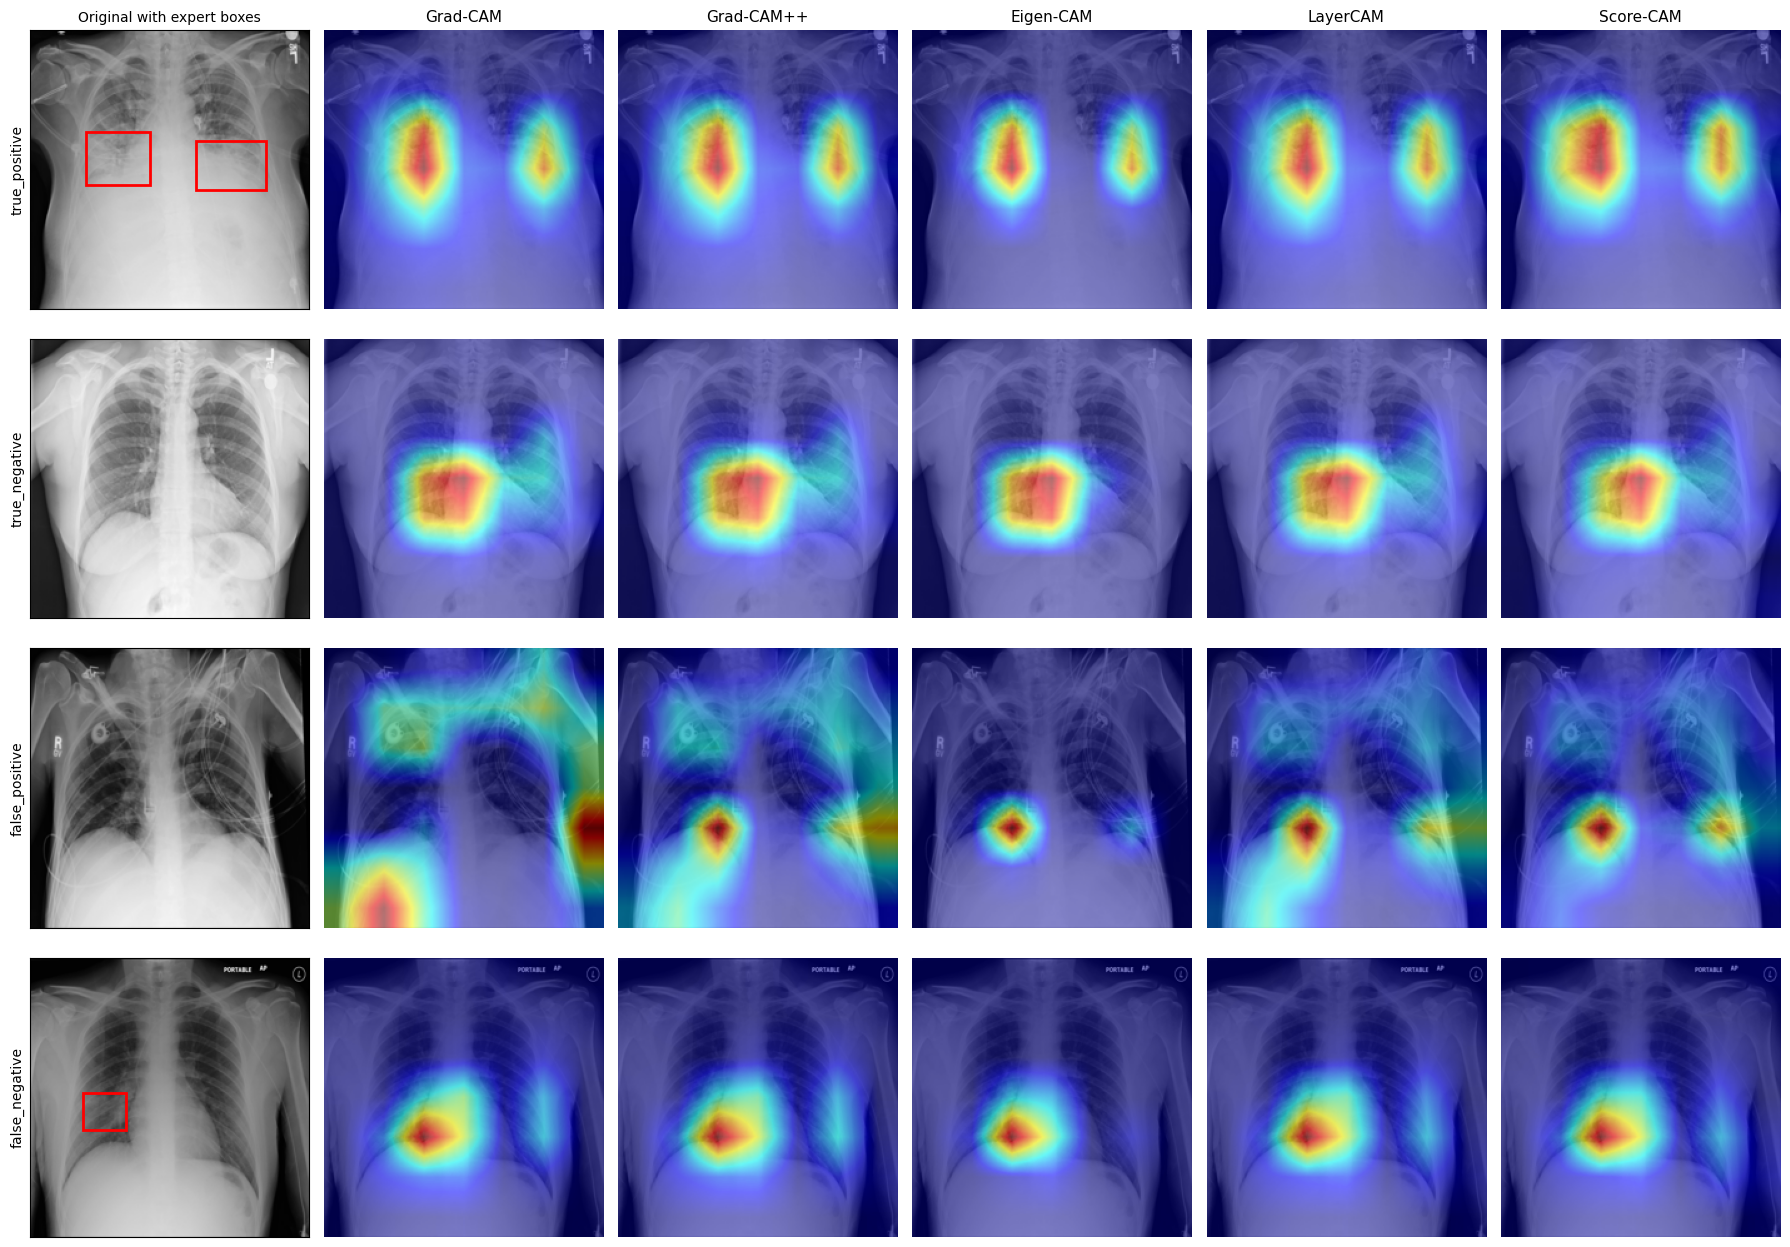

Outputs: ['__notebook__.ipynb', 'cam_comparison_figure.png', 'cam_faithfulness_scores.csv', 'cam_localization_scores.csv', 'cam_metrics_barplots.png', 'cam_summary.csv', 'heatmaps', 'heatmaps_rsna.zip']


In [9]:
method_order = ["gradcam", "gradcampp", "eigencam", "layercam", "scorecam"]
method_titles = ["Grad-CAM", "Grad-CAM++", "Eigen-CAM", "LayerCAM", "Score-CAM"]

examples = qual_set.groupby("category").head(1).reset_index(drop=True)
fig, axes = plt.subplots(len(examples), 6, figsize=(18, 3.2 * len(examples)))

for r, row in examples.iterrows():
    _, display, (h, w) = load_image(row["filepath"])
    axes[r, 0].imshow(display)
    for _, b in bboxes[bboxes["patientId"] == row["patientId"]].iterrows():
        axes[r, 0].add_patch(patches.Rectangle(
            (b["x"] / w * IMG_SIZE, b["y"] / h * IMG_SIZE),
            b["width"] / w * IMG_SIZE, b["height"] / h * IMG_SIZE,
            linewidth=2, edgecolor="red", facecolor="none"))
    axes[r, 0].set_ylabel(row["category"], fontsize=10)
    axes[r, 0].set_xticks([]); axes[r, 0].set_yticks([])
    if r == 0:
        axes[r, 0].set_title("Original with expert boxes", fontsize=10)
    for c, (name, title) in enumerate(zip(method_order, method_titles), start=1):
        overlay = Image.open(os.path.join(HEATMAP_DIR, f"{row['patientId']}__{name}.png"))
        axes[r, c].imshow(overlay)
        axes[r, c].axis("off")
        if r == 0:
            axes[r, c].set_title(title, fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "cam_comparison_figure.png"), dpi=200, bbox_inches="tight")
plt.show()

import shutil
shutil.make_archive(os.path.join(OUTPUT_DIR, "heatmaps_rsna"), "zip", HEATMAP_DIR)
print("Outputs:", sorted(os.listdir(OUTPUT_DIR)))